# Anamolous Behavoiur in Public image classsification model.

We are performing classification on 3000 images per class with class names :
* Blood or Riots detected in public
* Anamolous Face Mask in public detected
* Person with Gun in public detected
* Person with Knife in public detected
* No Anamolus behaviour in public

## Training Binary Classification Model
We are using tranfer learning to classify images.
EfficientnetB4 is used.

In [2]:
import tensorflow as tf
print("TensorFlow Version : ",tf.__version__)
print("TensorFlow GPU Available : ", len(tf.config.list_physical_devices('GPU')))
print("TF GPU Devices : ",tf.config.experimental.get_device_details(tf.config.list_physical_devices('GPU')[0]).get('device_name', 'Unknown'))

TensorFlow Version :  2.10.1
TensorFlow GPU Available :  1
TF GPU Devices :  NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()

105

### Importing Datasets

In [4]:
import os
import numpy as np
import pandas as pd

DATASET_DIR = r'dataset_anamolies/train'

IMG_HEIGHT = 224 # EfficientNetB4 default input
IMG_WIDTH = 224
BATCH_SIZE = 16   # Adjust based on available RAM/GPU
NUM_CLASSES = 5
N_SPLITS = 5
EPOCHS_HEAD = 5
EPOCHS_FINE_TUNE = 5
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE_TUNE = 1e-5
DROPOUT_RATE = 0.5

In [5]:
from sklearn.utils import shuffle

image_paths, labels = [], []
class_names = sorted(os.listdir(DATASET_DIR))
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(class_dir, img_name))
            labels.append(class_to_idx[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels)
image_paths, labels = shuffle(image_paths, labels, random_state=42)

In [6]:
class_to_idx

{'blood': 0, 'face_mask': 1, 'gun': 2, 'knife': 3, 'no_anamoly': 4}

In [7]:
labels.size,image_paths.size

(9400, 9400)

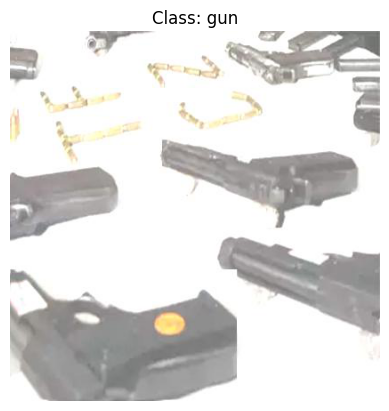

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
idx = 0
img = Image.open(image_paths[idx])
plt.imshow(img)
plt.title(f"Class: {class_names[labels[idx]]}")
plt.axis('off')
plt.show()

### Creating Model

In [9]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def create_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE):
    base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

### Training Model

In [10]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_accuracies = []
fold_f1_scores = []
fold_reports = []

for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, labels)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")
    train_paths, train_labels = image_paths[train_idx], labels[train_idx]
    val_paths, val_labels = image_paths[val_idx], labels[val_idx]

    preprocess_input = tf.keras.applications.efficientnet.preprocess_input

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_dataframe(
        pd.DataFrame({'filename': train_paths, 'class': train_labels.astype(str)}),
        x_col='filename',
        y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        classes=[str(i) for i in range(NUM_CLASSES)]
    )
    val_generator = val_datagen.flow_from_dataframe(
        pd.DataFrame({'filename': val_paths, 'class': val_labels.astype(str)}),
        x_col='filename',
        y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        classes=[str(i) for i in range(NUM_CLASSES)]
    )

    model = create_model()

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    checkpoint = ModelCheckpoint(f'best_model_fold_{fold+1}.h5', monitor='val_accuracy',verbose=1 , save_best_only=True, mode='max', save_weights_only=True)

    # Train head only
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(
        train_generator,
        epochs=EPOCHS_HEAD,
        validation_data=val_generator,
        callbacks=[early_stopping, reduce_lr, checkpoint],
    )
    model.load_weights(f'best_model_fold_{fold+1}.h5')

    # Fine-tune all layers
    model.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE_TUNE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(
        train_generator,
        epochs=EPOCHS_FINE_TUNE,
        validation_data=val_generator,
        callbacks=[early_stopping, reduce_lr, checkpoint]
    )
    model.load_weights(f'best_model_fold_{fold+1}.h5')

    # Evaluation
    val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
    fold_accuracies.append(float(val_accuracy))
    pred_probs = model.predict(val_generator)
    pred_labels = np.argmax(pred_probs, axis=1)
    true_labels = val_generator.classes
    target_names = class_names

    # Get classification report
    report = classification_report(true_labels, pred_labels, target_names=target_names, output_dict=True)
    
    # Convert all report values to native Python types
    def convert_to_native(obj):
        if isinstance(obj, dict):
            return {k: convert_to_native(v) for k, v in obj.items()}
        elif isinstance(obj, (np.floating, np.integer)):
            return obj.item()
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, tf.Tensor):
            return float(obj.numpy())
        else:
            return obj
    
    # Append safely converted values
    fold_f1_scores.append(float(report['weighted avg']['f1-score']))
    fold_reports.append(convert_to_native(report))

    print(f"Fold {fold+1} Classification Report:\n{classification_report(true_labels, pred_labels, target_names=target_names)}")


--- Fold 1/5 ---
Found 7520 validated image filenames belonging to 5 classes.
Found 1880 validated image filenames belonging to 5 classes.
Epoch 1/5
470/470 [==============================] - ETA: 0s - loss: 0.2004 - accuracy: 0.9319
Epoch 1: val_accuracy improved from -inf to 0.97872, saving model to best_model_fold_1.h5
470/470 [==============================] - 90s 174ms/step - loss: 0.2004 - accuracy: 0.9319 - val_loss: 0.0904 - val_accuracy: 0.9787 - lr: 0.0010
Epoch 2/5
470/470 [==============================] - ETA: 0s - loss: 0.1090 - accuracy: 0.9641
Epoch 2: val_accuracy improved from 0.97872 to 0.97979, saving model to best_model_fold_1.h5
470/470 [==============================] - 79s 169ms/step - loss: 0.1090 - accuracy: 0.9641 - val_loss: 0.0803 - val_accuracy: 0.9798 - lr: 0.0010
Epoch 3/5
470/470 [==============================] - ETA: 0s - loss: 0.0874 - accuracy: 0.9690
Epoch 3: val_accuracy improved from 0.97979 to 0.98191, saving model to best_model_fold_1.h5
470/4

In [18]:
print("\n--- Cross-Validation Summary ---")
print(f"Average Accuracy across {N_SPLITS} folds: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Average Weighted F1-Score across {N_SPLITS} folds: {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")


--- Cross-Validation Summary ---
Average Accuracy across 5 folds: 0.9849 ± 0.0023
Average Weighted F1-Score across 5 folds: 0.9849 ± 0.0023


## Testing Model

In [19]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TEST_DIR = 'dataset_anamolies/test'  # Change to the path of your "test" directory
IMG_HEIGHT = 380  # Use same size as during training
IMG_WIDTH = 380
BATCH_SIZE = 16  # Can adjust for your system

# Get the sorted class names as during training
class_names = sorted([f for f in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, f))])

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # Should match training generator
    shuffle=False  # Important for correct y_true order
)

Found 1953 images belonging to 5 classes.


In [24]:
model = create_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE_TUNE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model.load_weights(f'best_model_fold_{5}.h5')

In [25]:
# Evaluate on the test set and print metrics from model.compile
results = model.evaluate(test_generator, verbose=1)
print("\nTest Results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

123/123 [==============================] - 46s 342ms/step - loss: 0.0277 - accuracy: 0.9908

Test Results:
loss: 0.0277
accuracy: 0.9908


123/123 [==============================] - 20s 148ms/step
Classification Report:
               precision    recall  f1-score   support

       blood       0.99      0.99      0.99       100
   face_mask       0.99      0.99      0.99       353
         gun       0.98      0.99      0.99       500
       knife       1.00      0.99      0.99       500
  no_anamoly       1.00      0.99      0.99       500

    accuracy                           0.99      1953
   macro avg       0.99      0.99      0.99      1953
weighted avg       0.99      0.99      0.99      1953



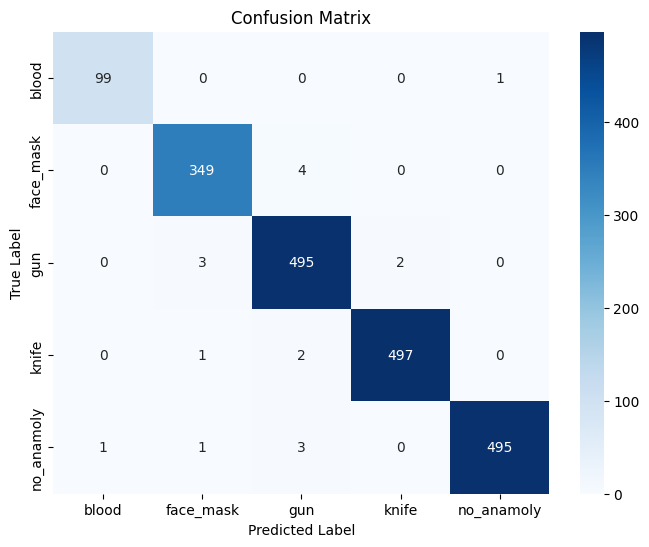

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict classes for the test set
pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

# Classification report: precision, recall, f1-score
cr = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", cr)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Optionally: plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Inference on unseen data

In [28]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import tensorflow as tf

In [43]:
IMG_HEIGHT = 224  # Same as used during training
IMG_WIDTH = 224

# List of your class names in correct order (used during training/testing)
class_names = class_names #{'blood': 0, 'face_mask': 1, 'gun': 2, 'knife': 3, 'no_anamoly': 4}

model = create_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE_TUNE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model.load_weights(f'best_model_fold_{5}.h5')
SINGLE_IMAGE_PATH = 'image1.jpg'

In [44]:
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet

In [45]:
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 2s 2s/step
Predicted class: blood
Prediction probabilities (per class): [1.000e+00 1.848e-06 1.687e-05 2.384e-06 1.538e-05]


In [52]:
SINGLE_IMAGE_PATH = 'a.jpg'
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 0s 53ms/step
Predicted class: face_mask
Prediction probabilities (per class): [5.96e-08 9.29e-01 7.08e-02 4.29e-06 1.19e-06]


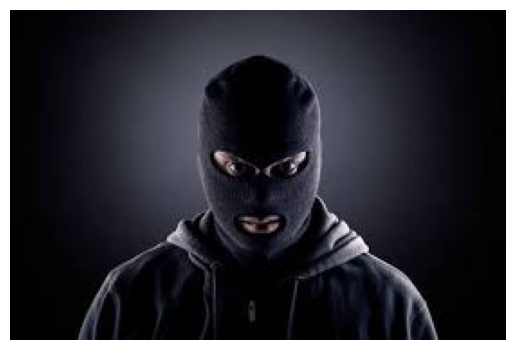

In [3]:
#Actual image
from PIL import Image
import matplotlib.pyplot as plt
img_path = 'a.jpg'
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()